This notebook is from https://github.com/nasaharvest/cropharvest/blob/main/demo.ipynb

# CropHarvest Demo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nasaharvest/cropharvest/blob/main/demo.ipynb)

**Authors**: Gabriel Tseng, Ivan Zvonkov

**Description**: This notebook demonstrates the capabilities of the CropHarvest package by training and testing a model on a subset of the data and then running inference using the trained model.

In [6]:
# Download from PyPI
#!pip install cropharvest -q

# Download from TestPyPI
#!pip install -i https://test.pypi.org/simple/ cropharvest --extra-index-url https://pypi.python.org/simple -q

In [7]:
#!pip freeze | grep cropharvest 

In [8]:
from cropharvest.datasets import CropHarvest
from cropharvest.inference import Inference
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier

import requests
import tempfile

DATA_DIR = "data"

!mkdir $DATA_DIR

A subdirectory or file data already exists.


## Load datasets

In [9]:
evaluation_datasets = CropHarvest.create_benchmark_datasets(DATA_DIR)
evaluation_datasets

[CropHarvestEval(Kenya_1_maize, Kenya_maize),
 CropHarvestEval(Brazil_0_coffee, Brazil_coffee),
 CropHarvestEval(Togo_crop, togo-eval),
 CropHarvestEval(People's Republic of China_11_crop, china-crop)]

## Split Togo data into X and y

In [10]:
togo_dataset = evaluation_datasets[-1]
X, y = togo_dataset.as_array(flatten_x=True)

#assert X.shape[0] == 1290
#assert y.shape[0] == 1290
#assert X.shape[1] == 216

X.shape, y.shape

((4142, 216), (4142,))

## Train a Random Forest model on the Togo dataset

In [11]:
model = RandomForestClassifier(random_state=0)
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Make predictions on Togo test set

In [12]:
test_preds, test_instances = [], []
for _, test_instance in togo_dataset.test_data(flatten_x=True):
    test_preds.append(model.predict_proba(test_instance.x)[:, 1])
    test_instances.append(test_instance)
    
print(
    f"For the Random Forest classifier, "
    f"{test_instances[0].evaluate_predictions(test_preds[0])}, "
)

metrics = test_instances[0].evaluate_predictions(test_preds[0])
assert metrics["f1_score"] > 0.73, "Default model f1-score should be greater than 0.73"
assert metrics["auc_roc"] > 0.88, "Default model AUC-ROC should be greater than 0.88"

For the Random Forest classifier, {'auc_roc': 0.8496120601618732, 'f1_score': 0.8220901782593498, 'iou': 0.6979228486646885, 'num_samples': 4397}, 


AssertionError: Default model AUC-ROC should be greater than 0.88

## Get test file for inference

In [13]:
test_file = "98-togo_2019-02-06_2020-02-01.tif"

temp_dir = tempfile.gettempdir()
p = Path(temp_dir) / test_file
response = requests.get(
    f"https://github.com/nasaharvest/cropharvest/blob/main/test/cropharvest/{test_file}?raw=true", 
)
with p.open("wb") as f:
    f.write(response.content)

## Run inference

In [14]:
preds = Inference(model=model, normalizing_dict=None).run(p)

# Check size
assert preds.dims["lat"] == 17
assert preds.dims["lon"] == 17

# Check all predictions between 0 and 1
assert preds.min() >= 0
assert preds.max() <= 1

preds

<xarray.Dataset>
Dimensions:       (lat: 17, lon: 17)
Coordinates:
  * lat           (lat) float64 7.719 7.719 7.719 7.719 ... 7.72 7.72 7.72 7.72
  * lon           (lon) float64 1.422 1.422 1.422 1.422 ... 1.423 1.423 1.424
Data variables:
    prediction_0  (lat, lon) float64 0.46 0.46 0.46 0.46 ... 0.47 0.47 0.47 0.46

## [Optional] Visualize model prediction

In [ ]:
#!pip install matplotlib -q

In [15]:
import matplotlib.pyplot as plt

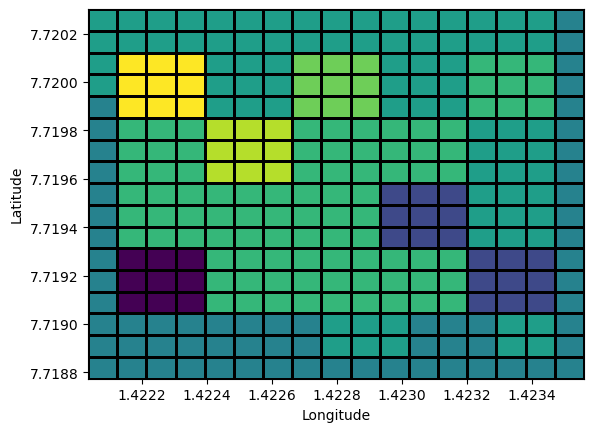

In [18]:
preds_np = preds.to_array()[0]
plt.pcolormesh(preds_np.lon, preds_np.lat, preds_np.data, ec='k')
plt.xlabel("Longitude")
plt.ylabel("Latitude");

In [17]:
preds_np.shape

(17, 17)

In [19]:
print(preds_np.data)

[[0.46 0.46 0.46 0.46 0.46 0.46 0.46 0.46 0.46 0.46 0.46 0.46 0.46 0.46
  0.46 0.46 0.46]
 [0.46 0.46 0.46 0.46 0.46 0.46 0.46 0.46 0.47 0.47 0.47 0.46 0.46 0.46
  0.47 0.47 0.46]
 [0.46 0.46 0.46 0.46 0.46 0.46 0.46 0.46 0.47 0.47 0.47 0.46 0.46 0.46
  0.47 0.47 0.46]
 [0.46 0.42 0.42 0.42 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.44
  0.44 0.44 0.46]
 [0.46 0.42 0.42 0.42 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.44
  0.44 0.44 0.46]
 [0.46 0.42 0.42 0.42 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.44
  0.44 0.44 0.46]
 [0.46 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.44 0.44 0.44 0.47
  0.47 0.47 0.46]
 [0.46 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.44 0.44 0.44 0.47
  0.47 0.47 0.46]
 [0.46 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.48 0.44 0.44 0.44 0.47
  0.47 0.47 0.46]
 [0.46 0.48 0.48 0.48 0.5  0.5  0.5  0.48 0.48 0.48 0.48 0.48 0.48 0.47
  0.47 0.47 0.46]
 [0.46 0.48 0.48 0.48 0.5  0.5  0.5  0.48 0.48 0.48 0.48 0.48 0.48 0.47
  0.47 0.47 0.46]
 [0.46 0.4